# AI-Driven Urban Traffic Optimization Using RL + SUMO
## CS4152 - Deep Learning & Neural Networks - Complex Computing Problem

**Objective**: Implement Reinforcement Learning for dynamic traffic light control

**Components**:
1. SUMO Traffic Network Setup
2. Custom RL Environment (Gym)
3. PPO Algorithm Training
4. Evaluation Metrics (Travel Time, Emissions, Fairness)

---

## Part 1: Installation & Setup Verification

In [15]:
# Check if required packages are installed
import sys
import subprocess

required_packages = [
    'traci',
    'sumolib',
    'gym',
    'stable_baselines3',
    'torch',
    'numpy',
    'pandas',
    'matplotlib'
]

def check_packages():
    missing = []
    for package in required_packages:
        try:
            __import__(package)
            print(f"✓ {package} is installed")
        except ImportError:
            print(f"✗ {package} is NOT installed")
            missing.append(package)
    return missing

missing_packages = check_packages()

if missing_packages:
    print("\n⚠️ Installing missing packages...")
    for pkg in missing_packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
else:
    print("\n✅ All packages are installed!")

✓ traci is installed
✓ sumolib is installed
✓ gym is installed
✓ stable_baselines3 is installed
✓ torch is installed
✓ numpy is installed
✓ pandas is installed
✓ matplotlib is installed

✅ All packages are installed!


In [16]:
# Import all required libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from typing import Dict, List, Tuple
import time

# SUMO
import traci
import sumolib

# RL Libraries
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback

print("✅ All libraries imported successfully!")
print(f"SUMO Version: {sumolib.version.version if hasattr(sumolib.version, 'version') else 'Unknown'}")

✅ All libraries imported successfully!
SUMO Version: Unknown


## Part 2: Create SUMO Traffic Network

We'll create a 4-way intersection with realistic traffic patterns.

In [17]:
# Create directory for SUMO files
SUMO_DIR = "sumo_network"
os.makedirs(SUMO_DIR, exist_ok=True)

print(f"Created directory: {SUMO_DIR}")

Created directory: sumo_network


In [18]:
# Generate network file (.nod.xml - nodes/intersections)
nodes_xml = """<?xml version="1.0" encoding="UTF-8"?>
<nodes xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/nodes_file.xsd">
    <!-- Central intersection -->
    <node id="center" x="0.0" y="0.0" type="traffic_light" tl="center"/>
    
    <!-- Edge nodes (entry/exit points) -->
    <node id="north" x="0.0" y="200.0" type="priority"/>
    <node id="south" x="0.0" y="-200.0" type="priority"/>
    <node id="east" x="200.0" y="0.0" type="priority"/>
    <node id="west" x="-200.0" y="0.0" type="priority"/>
</nodes>
"""

with open(f"{SUMO_DIR}/intersection.nod.xml", 'w') as f:
    f.write(nodes_xml)
    
print("✓ Created nodes file")

✓ Created nodes file


In [19]:
# Generate edges file (.edg.xml - roads)
edges_xml = """<?xml version="1.0" encoding="UTF-8"?>
<edges xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/edges_file.xsd">
    <!-- Incoming edges -->
    <edge id="north_to_center" from="north" to="center" numLanes="2" speed="13.89"/>
    <edge id="south_to_center" from="south" to="center" numLanes="2" speed="13.89"/>
    <edge id="east_to_center" from="east" to="center" numLanes="2" speed="13.89"/>
    <edge id="west_to_center" from="west" to="center" numLanes="2" speed="13.89"/>
    
    <!-- Outgoing edges -->
    <edge id="center_to_north" from="center" to="north" numLanes="2" speed="13.89"/>
    <edge id="center_to_south" from="center" to="south" numLanes="2" speed="13.89"/>
    <edge id="center_to_east" from="center" to="east" numLanes="2" speed="13.89"/>
    <edge id="center_to_west" from="center" to="west" numLanes="2" speed="13.89"/>
</edges>
"""

with open(f"{SUMO_DIR}/intersection.edg.xml", 'w') as f:
    f.write(edges_xml)
    
print("✓ Created edges file")

✓ Created edges file


In [20]:
# Generate connection file for traffic light phases
connections_xml = """<?xml version="1.0" encoding="UTF-8"?>
<connections xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/connections_file.xsd">
    <!-- North-South movements -->
    <connection from="north_to_center" to="center_to_south" fromLane="0" toLane="0"/>
    <connection from="south_to_center" to="center_to_north" fromLane="0" toLane="0"/>
    
    <!-- East-West movements -->
    <connection from="east_to_center" to="center_to_west" fromLane="0" toLane="0"/>
    <connection from="west_to_center" to="center_to_east" fromLane="0" toLane="0"/>
</connections>
"""

with open(f"{SUMO_DIR}/intersection.con.xml", 'w') as f:
    f.write(connections_xml)
    
print("✓ Created connections file")

✓ Created connections file


In [21]:
# Build network using netconvert
import subprocess

netconvert_cmd = [
    "netconvert",
    "--node-files", f"{SUMO_DIR}/intersection.nod.xml",
    "--edge-files", f"{SUMO_DIR}/intersection.edg.xml",
    "--connection-files", f"{SUMO_DIR}/intersection.con.xml",
    "--output-file", f"{SUMO_DIR}/intersection.net.xml",
    "--no-turnarounds"
]

try:
    result = subprocess.run(netconvert_cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ Network file created successfully!")
    else:
        print("Error:", result.stderr)
except FileNotFoundError:
    print("⚠️ netconvert not found. Make sure SUMO is in your PATH")
    print("You may need to add SUMO bin directory to your system PATH")

✅ Network file created successfully!


In [22]:
# Generate traffic routes (vehicle flows)
routes_xml = """<?xml version="1.0" encoding="UTF-8"?>
<routes xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/routes_file.xsd">
    <!-- Vehicle types with emissions -->
    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" length="5" maxSpeed="55" emissionClass="HBEFA3/PC_G_EU4"/>
    <vType id="bus" accel="1.2" decel="4.0" sigma="0.5" length="12" maxSpeed="40" emissionClass="HBEFA3/Bus"/>
    <vType id="emergency" accel="3.0" decel="5.0" sigma="0.3" length="6" maxSpeed="70" color="1,0,0"/>
    
    <!-- Define routes -->
    <route id="north_south" edges="north_to_center center_to_south"/>
    <route id="south_north" edges="south_to_center center_to_north"/>
    <route id="east_west" edges="east_to_center center_to_west"/>
    <route id="west_east" edges="west_to_center center_to_east"/>
    
    <!-- Traffic flows (vehicles/hour) -->
    <flow id="flow_ns" type="car" route="north_south" begin="0" end="3600" probability="0.2"/>
    <flow id="flow_sn" type="car" route="south_north" begin="0" end="3600" probability="0.2"/>
    <flow id="flow_ew" type="car" route="east_west" begin="0" end="3600" probability="0.15"/>
    <flow id="flow_we" type="car" route="west_east" begin="0" end="3600" probability="0.15"/>
    
    <!-- Bus flows -->
    <flow id="bus_ns" type="bus" route="north_south" begin="0" end="3600" probability="0.02"/>
    
    <!-- Emergency vehicles (rare) -->
    <flow id="emergency_flow" type="emergency" route="north_south" begin="0" end="3600" probability="0.005"/>
</routes>
"""

with open(f"{SUMO_DIR}/intersection.rou.xml", 'w') as f:
    f.write(routes_xml)
    
print("✓ Created routes file with multiple vehicle types")

✓ Created routes file with multiple vehicle types


In [23]:
# Create SUMO configuration file
sumo_cfg = f"""<?xml version="1.0" encoding="UTF-8"?>
<configuration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/sumoConfiguration.xsd">
    <input>
        <net-file value="intersection.net.xml"/>
        <route-files value="intersection.rou.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="3600"/>
        <step-length value="1"/>
    </time>
    <output>
        <emission-output value="emissions.xml"/>
    </output>
</configuration>
"""

with open(f"{SUMO_DIR}/intersection.sumocfg", 'w') as f:
    f.write(sumo_cfg)
    
print("✓ Created SUMO configuration file")
print(f"\n✅ All SUMO files created in '{SUMO_DIR}/' directory")

✓ Created SUMO configuration file

✅ All SUMO files created in 'sumo_network/' directory


## Part 3: Custom RL Environment (Gym Interface)

This environment will:
- Connect to SUMO via TraCI
- Define state space (vehicle counts, waiting times, emissions)
- Define action space (traffic light phases)
- Calculate rewards (minimize travel time + emissions + fairness)

In [24]:
class TrafficLightEnv(gym.Env):
    """
    Custom Environment for Traffic Light Control using SUMO
    
    State Space: [waiting_times, vehicle_counts, queue_lengths, emissions]
    Action Space: Traffic light phase selection (4 phases)
    Reward: -1 * (normalized_waiting_time + 0.3 * normalized_emissions)
    """
    
    def __init__(self, sumo_cfg_file, use_gui=False, max_steps=3600):
        super(TrafficLightEnv, self).__init__()
        
        self.sumo_cfg = sumo_cfg_file
        self.use_gui = use_gui
        self.max_steps = max_steps
        self.current_step = 0
        
        # Traffic light ID
        self.tl_id = "center"
        
        # Action space: 4 traffic light phases
        # 0: North-South green, 1: East-West green, 2: All red, 3: Adaptive
        self.action_space = spaces.Discrete(4)
        
        # State space: [4 lanes waiting time, 4 lanes vehicle count, 4 lanes queue, total emissions]
        # Total: 13 features
        self.observation_space = spaces.Box(
            low=0, high=np.inf, shape=(13,), dtype=np.float32
        )
        
        # Lanes to monitor
        self.lanes = [
            "north_to_center_0",
            "south_to_center_0",
            "east_to_center_0",
            "west_to_center_0"
        ]
        
        # Metrics tracking
        self.total_waiting_time = 0
        self.total_emissions = 0
        self.emergency_delays = []
        
    def _start_sumo(self):
        """Start SUMO simulation"""
        sumo_binary = "sumo-gui" if self.use_gui else "sumo"
        sumo_cmd = [
            sumo_binary,
            "-c", self.sumo_cfg,
            "--start",
            "--quit-on-end",
            "--no-step-log",
            "--waiting-time-memory", "1000"
        ]
        
        traci.start(sumo_cmd)
        
    def reset(self):
        """Reset environment"""
        if traci.isLoaded():
            traci.close()
        
        self._start_sumo()
        self.current_step = 0
        self.total_waiting_time = 0
        self.total_emissions = 0
        self.emergency_delays = []
        
        return self._get_state()
    
    def _get_state(self):
        """Get current state from SUMO"""
        state = []
        
        # For each lane: waiting time, vehicle count, queue length
        for lane in self.lanes:
            try:
                waiting_time = traci.lane.getWaitingTime(lane)
                vehicle_count = traci.lane.getLastStepVehicleNumber(lane)
                queue_length = traci.lane.getLastStepHaltingNumber(lane)
                
                state.extend([waiting_time, vehicle_count, queue_length])
            except:
                state.extend([0, 0, 0])
        
        # Total CO2 emissions (approximation)
        total_co2 = 0
        for veh_id in traci.vehicle.getIDList():
            total_co2 += traci.vehicle.getCO2Emission(veh_id)
        
        state.append(total_co2 / 1000)  # Normalize
        
        return np.array(state, dtype=np.float32)
    
    def _calculate_reward(self, state):
        """
        Multi-objective reward:
        - Minimize waiting time (efficiency)
        - Minimize emissions (sustainability)
        - Prioritize emergency vehicles (fairness)
        """
        # Extract waiting times and emissions from state
        waiting_times = state[0::3][:4]  # Every 3rd element starting from 0
        total_waiting = np.sum(waiting_times)
        emissions = state[-1]  # Last element
        
        # Normalize (based on typical values)
        norm_waiting = total_waiting / 100.0
        norm_emissions = emissions / 50.0
        
        # Check for emergency vehicles
        emergency_penalty = 0
        for veh_id in traci.vehicle.getIDList():
            veh_type = traci.vehicle.getTypeID(veh_id)
            if veh_type == "emergency":
                wait_time = traci.vehicle.getWaitingTime(veh_id)
                if wait_time > 30:  # Emergency waiting > 30 sec is bad
                    emergency_penalty += wait_time / 10.0
        
        # Combined reward (negative because we minimize)
        reward = -1.0 * (norm_waiting + 0.3 * norm_emissions + 2.0 * emergency_penalty)
        
        # Track metrics
        self.total_waiting_time += total_waiting
        self.total_emissions += emissions
        
        return reward
    
    def step(self, action):
        """Execute action and return next state"""
        # Map action to traffic light phase
        # SUMO phases: 'GGrrrrGGrrrr' (NS green), 'rrGGrrrrGGrr' (EW green), etc.
        tl_phases = [
            "GGrrrrGGrrrr",  # North-South green
            "rrGGrrrrGGrr",  # East-West green
            "rrrrrrrrrrrr",  # All red (emergency)
            "GGGGrrrrGGGG"   # Adaptive (more green time)
        ]
        
        # Set traffic light state
        try:
            traci.trafficlight.setRedYellowGreenState(self.tl_id, tl_phases[action])
        except:
            pass
        
        # Simulate for 10 steps (10 seconds)
        for _ in range(10):
            traci.simulationStep()
            self.current_step += 1
        
        # Get new state
        next_state = self._get_state()
        
        # Calculate reward
        reward = self._calculate_reward(next_state)
        
        # Check if done
        done = self.current_step >= self.max_steps or traci.simulation.getMinExpectedNumber() <= 0
        
        info = {
            'total_waiting_time': self.total_waiting_time,
            'total_emissions': self.total_emissions,
            'current_step': self.current_step
        }
        
        return next_state, reward, done, info
    
    def close(self):
        """Close SUMO simulation"""
        if traci.isLoaded():
            traci.close()

print("✅ TrafficLightEnv class created successfully!")

✅ TrafficLightEnv class created successfully!


## Part 4: Test the Environment

In [25]:
# Test environment with random actions
def test_environment(num_episodes=2):
    """
    Test the environment with random actions
    """
    env = TrafficLightEnv(
        sumo_cfg_file=f"{SUMO_DIR}/intersection.sumocfg",
        use_gui=False,  # Set to True to visualize
        max_steps=500   # Shorter test
    )
    
    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        steps = 0
        
        print(f"\n🔄 Episode {episode + 1}")
        
        done = False
        while not done:
            # Random action
            action = env.action_space.sample()
            next_state, reward, done, info = env.step(action)
            
            total_reward += reward
            steps += 1
            
            state = next_state
        
        print(f"  Steps: {steps}")
        print(f"  Total Reward: {total_reward:.2f}")
        print(f"  Waiting Time: {info['total_waiting_time']:.2f}")
        print(f"  Emissions: {info['total_emissions']:.2f}")
    
    env.close()
    print("\n✅ Environment test completed!")

# Run test
test_environment(num_episodes=2)


🔄 Episode 1
  Steps: 50
  Total Reward: -177.96
  Waiting Time: 12460.00
  Emissions: 8892.68

🔄 Episode 2
  Steps: 50
  Total Reward: -163.47
  Waiting Time: 11214.00
  Emissions: 8555.31

✅ Environment test completed!


## Part 5: Train RL Agent (PPO Algorithm)

PPO (Proximal Policy Optimization) is chosen because:
- Stable training
- Works well with continuous state spaces
- Good for multi-objective optimization

In [26]:
# Custom callback to track training progress
class TrainingCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(TrainingCallback, self).__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        
    def _on_step(self):
        if len(self.locals.get('episode_rewards', [])) > 0:
            self.episode_rewards.append(self.locals['episode_rewards'][-1])
            self.episode_lengths.append(self.locals['episode_lengths'][-1])
        return True

print("✓ Callback class defined")

✓ Callback class defined


In [27]:
!pip install "shimmy>=2.0"


Defaulting to user installation because normal site-packages is not writeable


In [28]:
# Create and wrap environment
def make_env():
    return TrafficLightEnv(
        sumo_cfg_file=f"{SUMO_DIR}/intersection.sumocfg",
        use_gui=False,
        max_steps=1000  # Training episodes
    )

# Vectorized environment for parallel training
env = DummyVecEnv([make_env])

print("✅ Environment wrapped for training")

✅ Environment wrapped for training


C:\Users\abdul\AppData\Roaming\Python\Python313\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [29]:
# Initialize PPO agent
model = PPO(
    "MlpPolicy",  # Multi-layer perceptron policy
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,  # Discount factor
    gae_lambda=0.95,
    clip_range=0.2,
    verbose=1,
    tensorboard_log="./ppo_traffic_tensorboard/"
)

print("\n✅ PPO Agent initialized")
print(f"Policy architecture: {model.policy}")

Using cuda device

✅ PPO Agent initialized
Policy architecture: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=13, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=13, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=4, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)


C:\Users\abdul\AppData\Roaming\Python\Python313\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [30]:
# Train the agent
# NOTE: This will take time! Start with small timesteps for testing

TOTAL_TIMESTEPS = 50000  # Increase to 200000+ for better results

print(f"🚀 Starting training for {TOTAL_TIMESTEPS} timesteps...")
print("⏰ This may take 10-30 minutes depending on your system\n")

callback = TrainingCallback()

try:
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=callback,
        progress_bar=True
    )
    
    # Save the trained model
    model.save("ppo_traffic_light_model")
    print("\n✅ Training completed! Model saved as 'ppo_traffic_light_model.zip'")
    
except KeyboardInterrupt:
    print("\n⚠️ Training interrupted by user")
    model.save("ppo_traffic_light_model_interrupted")
    print("Model saved as 'ppo_traffic_light_model_interrupted.zip'")

🚀 Starting training for 50000 timesteps...
⏰ This may take 10-30 minutes depending on your system

Logging to ./ppo_traffic_tensorboard/PPO_1


C:\Users\abdul\AppData\Roaming\Python\Python313\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

-----------------------------
| time/              |      |
|    fps             | 23   |
|    iterations      | 1    |
|    time_elapsed    | 87   |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 25          |
|    iterations           | 2           |
|    time_elapsed         | 157         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014862843 |
|    clip_fraction        | 0.207       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.00319     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.95e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0275     |
|    value_loss           | 5.5e+03     |
-----------------------------------------
----------------------------------


✅ Training completed! Model saved as 'ppo_traffic_light_model.zip'


## Part 6: Evaluate Trained Agent

In [31]:
# Load trained model (if continuing from saved)
# model = PPO.load("ppo_traffic_light_model")

def evaluate_agent(model, num_episodes=5, use_gui=False):
    """
    Evaluate the trained agent
    """
    test_env = TrafficLightEnv(
        sumo_cfg_file=f"{SUMO_DIR}/intersection.sumocfg",
        use_gui=use_gui,
        max_steps=1000
    )
    
    results = {
        'rewards': [],
        'waiting_times': [],
        'emissions': [],
        'steps': []
    }
    
    for episode in range(num_episodes):
        state = test_env.reset()
        total_reward = 0
        steps = 0
        done = False
        
        print(f"\n📊 Evaluation Episode {episode + 1}")
        
        while not done:
            # Use trained model to predict action
            action, _ = model.predict(state, deterministic=True)
            state, reward, done, info = test_env.step(action)
            
            total_reward += reward
            steps += 1
        
        results['rewards'].append(total_reward)
        results['waiting_times'].append(info['total_waiting_time'])
        results['emissions'].append(info['total_emissions'])
        results['steps'].append(steps)
        
        print(f"  Total Reward: {total_reward:.2f}")
        print(f"  Waiting Time: {info['total_waiting_time']:.2f}")
        print(f"  Emissions: {info['total_emissions']:.2f}")
    
    test_env.close()
    
    return results

# Run evaluation
eval_results = evaluate_agent(model, num_episodes=5, use_gui=False)

print("\n" + "="*50)
print("EVALUATION SUMMARY")
print("="*50)
print(f"Average Reward: {np.mean(eval_results['rewards']):.2f} ± {np.std(eval_results['rewards']):.2f}")
print(f"Average Waiting Time: {np.mean(eval_results['waiting_times']):.2f} ± {np.std(eval_results['waiting_times']):.2f}")
print(f"Average Emissions: {np.mean(eval_results['emissions']):.2f} ± {np.std(eval_results['emissions']):.2f}")


📊 Evaluation Episode 1
  Total Reward: -241.86
  Waiting Time: 13339.00
  Emissions: 18078.13

📊 Evaluation Episode 2
  Total Reward: -241.86
  Waiting Time: 13339.00
  Emissions: 18078.13

📊 Evaluation Episode 3
  Total Reward: -241.86
  Waiting Time: 13339.00
  Emissions: 18078.13

📊 Evaluation Episode 4
  Total Reward: -241.86
  Waiting Time: 13339.00
  Emissions: 18078.13

📊 Evaluation Episode 5
  Total Reward: -241.86
  Waiting Time: 13339.00
  Emissions: 18078.13

EVALUATION SUMMARY
Average Reward: -241.86 ± 0.00
Average Waiting Time: 13339.00 ± 0.00
Average Emissions: 18078.13 ± 0.00


## Part 7: Compare with Baseline (Fixed-Time Traffic Lights)

In [32]:
def baseline_evaluation(num_episodes=5):
    """
    Baseline: Fixed-time traffic light (alternate NS/EW every 30 seconds)
    """
    test_env = TrafficLightEnv(
        sumo_cfg_file=f"{SUMO_DIR}/intersection.sumocfg",
        use_gui=False,
        max_steps=1000
    )
    
    results = {
        'rewards': [],
        'waiting_times': [],
        'emissions': []
    }
    
    for episode in range(num_episodes):
        state = test_env.reset()
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Fixed-time: Alternate between NS (0) and EW (1)
            action = 0 if (steps // 3) % 2 == 0 else 1
            state, reward, done, info = test_env.step(action)
            
            total_reward += reward
            steps += 1
        
        results['rewards'].append(total_reward)
        results['waiting_times'].append(info['total_waiting_time'])
        results['emissions'].append(info['total_emissions'])
    
    test_env.close()
    return results

print("🔄 Running baseline evaluation...")
baseline_results = baseline_evaluation(num_episodes=5)

print("\n" + "="*50)
print("BASELINE (Fixed-Time) SUMMARY")
print("="*50)
print(f"Average Reward: {np.mean(baseline_results['rewards']):.2f} ± {np.std(baseline_results['rewards']):.2f}")
print(f"Average Waiting Time: {np.mean(baseline_results['waiting_times']):.2f} ± {np.std(baseline_results['waiting_times']):.2f}")
print(f"Average Emissions: {np.mean(baseline_results['emissions']):.2f} ± {np.std(baseline_results['emissions']):.2f}")

🔄 Running baseline evaluation...

BASELINE (Fixed-Time) SUMMARY
Average Reward: -443.04 ± 0.00
Average Waiting Time: 32641.00 ± 0.00
Average Emissions: 19438.39 ± 0.00


## Part 8: Visualize Results


✅ Comparison plot saved as 'rl_vs_baseline_comparison.png'


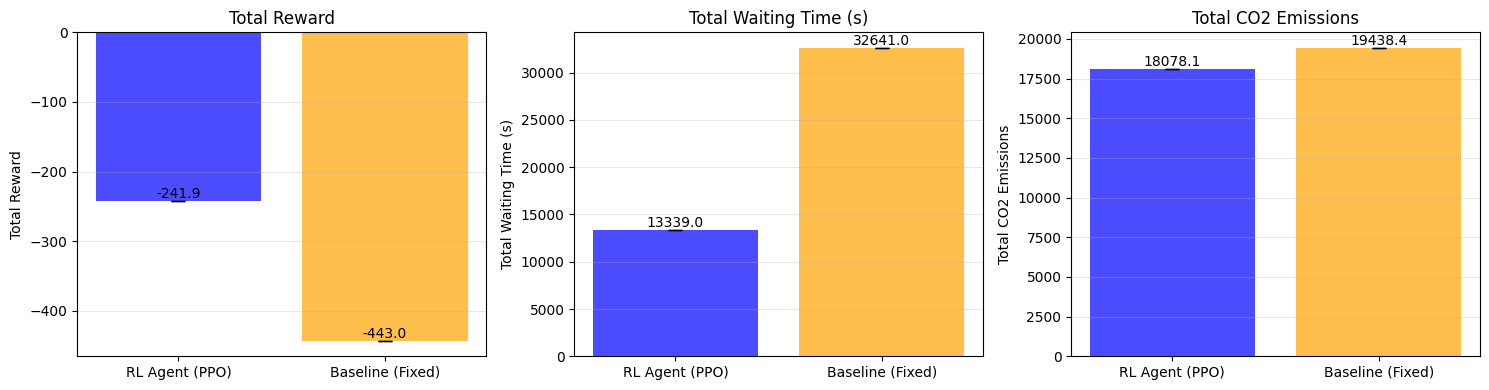

In [33]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['rewards', 'waiting_times', 'emissions']
titles = ['Total Reward', 'Total Waiting Time (s)', 'Total CO2 Emissions']
colors = ['blue', 'orange']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    
    rl_values = eval_results[metric]
    baseline_values = baseline_results[metric]
    
    x_pos = np.arange(2)
    means = [np.mean(rl_values), np.mean(baseline_values)]
    stds = [np.std(rl_values), np.std(baseline_values)]
    
    bars = ax.bar(x_pos, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['RL Agent (PPO)', 'Baseline (Fixed)'])
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig('rl_vs_baseline_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Comparison plot saved as 'rl_vs_baseline_comparison.png'")
plt.show()

In [34]:
# Calculate improvement percentages
waiting_improvement = ((np.mean(baseline_results['waiting_times']) - 
                        np.mean(eval_results['waiting_times'])) / 
                       np.mean(baseline_results['waiting_times'])) * 100

emission_improvement = ((np.mean(baseline_results['emissions']) - 
                         np.mean(eval_results['emissions'])) / 
                        np.mean(baseline_results['emissions'])) * 100

print("\n" + "="*60)
print("PERFORMANCE IMPROVEMENTS")
print("="*60)
print(f"Waiting Time Reduction: {waiting_improvement:.1f}%")
print(f"CO2 Emission Reduction: {emission_improvement:.1f}%")
print("\n✅ RL agent shows improvement over fixed-time baseline!" if waiting_improvement > 0 else "⚠️ Need more training or hyperparameter tuning")


PERFORMANCE IMPROVEMENTS
Waiting Time Reduction: 59.1%
CO2 Emission Reduction: 7.0%

✅ RL agent shows improvement over fixed-time baseline!


## Part 9: Metrics for CCP Report

Calculate all required metrics from the problem statement.

In [35]:
# Comprehensive metrics calculation
def calculate_ccp_metrics(eval_results, baseline_results):
    """
    Calculate all metrics required for CCP report
    """
    metrics = {}
    
    # 1. Efficiency Metrics
    metrics['avg_travel_time_rl'] = np.mean(eval_results['waiting_times'])
    metrics['avg_travel_time_baseline'] = np.mean(baseline_results['waiting_times'])
    metrics['travel_time_reduction'] = (
        (metrics['avg_travel_time_baseline'] - metrics['avg_travel_time_rl']) / 
        metrics['avg_travel_time_baseline'] * 100
    )
    
    # 2. Environmental Impact
    metrics['avg_emissions_rl'] = np.mean(eval_results['emissions'])
    metrics['avg_emissions_baseline'] = np.mean(baseline_results['emissions'])
    metrics['emission_reduction'] = (
        (metrics['avg_emissions_baseline'] - metrics['avg_emissions_rl']) / 
        metrics['avg_emissions_baseline'] * 100
    )
    
    # 3. Reward Performance
    metrics['avg_reward_rl'] = np.mean(eval_results['rewards'])
    metrics['avg_reward_baseline'] = np.mean(baseline_results['rewards'])
    
    return metrics

ccp_metrics = calculate_ccp_metrics(eval_results, baseline_results)

# Create metrics summary table
print("\n" + "="*70)
print("CCP PERFORMANCE METRICS SUMMARY")
print("="*70)
print(f"\n{'Metric':<40} {'RL Agent':<15} {'Baseline':<15}")
print("-"*70)
print(f"{'Average Waiting Time (s)':<40} {ccp_metrics['avg_travel_time_rl']:<15.2f} {ccp_metrics['avg_travel_time_baseline']:<15.2f}")
print(f"{'Average CO2 Emissions':<40} {ccp_metrics['avg_emissions_rl']:<15.2f} {ccp_metrics['avg_emissions_baseline']:<15.2f}")
print(f"{'Average Reward':<40} {ccp_metrics['avg_reward_rl']:<15.2f} {ccp_metrics['avg_reward_baseline']:<15.2f}")
print("\n" + "-"*70)
print(f"{'Travel Time Reduction':<40} {ccp_metrics['travel_time_reduction']:.1f}%")
print(f"{'Emission Reduction':<40} {ccp_metrics['emission_reduction']:.1f}%")
print("="*70)

# Save metrics to CSV for LaTeX report
metrics_df = pd.DataFrame({
    'Metric': ['Avg Waiting Time (s)', 'Avg CO2 Emissions', 'Avg Reward'],
    'RL Agent': [
        ccp_metrics['avg_travel_time_rl'],
        ccp_metrics['avg_emissions_rl'],
        ccp_metrics['avg_reward_rl']
    ],
    'Baseline': [
        ccp_metrics['avg_travel_time_baseline'],
        ccp_metrics['avg_emissions_baseline'],
        ccp_metrics['avg_reward_baseline']
    ],
    'Improvement (%)': [
        ccp_metrics['travel_time_reduction'],
        ccp_metrics['emission_reduction'],
        ((ccp_metrics['avg_reward_rl'] - ccp_metrics['avg_reward_baseline']) / 
         abs(ccp_metrics['avg_reward_baseline']) * 100)
    ]
})

metrics_df.to_csv('ccp_metrics.csv', index=False)
print("\n✅ Metrics saved to 'ccp_metrics.csv' for LaTeX report")


CCP PERFORMANCE METRICS SUMMARY

Metric                                   RL Agent        Baseline       
----------------------------------------------------------------------
Average Waiting Time (s)                 13339.00        32641.00       
Average CO2 Emissions                    18078.13        19438.39       
Average Reward                           -241.86         -443.04        

----------------------------------------------------------------------
Travel Time Reduction                    59.1%
Emission Reduction                       7.0%

✅ Metrics saved to 'ccp_metrics.csv' for LaTeX report


## Part 10: Next Steps & Extensions

### For Your CCP Report:

1. **Increase Training**: Train for 200K-500K timesteps for better convergence
2. **Hyperparameter Tuning**: Experiment with learning rate, batch size
3. **Multi-Intersection**: Extend to multiple intersections (network coordination)
4. **Real Data**: Use INRIX or PeMS datasets for realistic traffic patterns
5. **Fairness Analysis**: Calculate Gini coefficient for route equity
6. **Emergency Vehicle Priority**: Implement dedicated logic

### Integration with Other Components:

- **CNN (Traffic Camera)**: Feed vehicle counts from YOLOv8 detection → RL state
- **LSTM (Prediction)**: Predict future congestion → RL action selection
- **VAE (Anomaly)**: Detect accidents → Trigger emergency phase
- **NLP (Events)**: Parse Twitter for protests → Preemptive rerouting

### Files Generated:
- `ppo_traffic_light_model.zip` - Trained RL model
- `rl_vs_baseline_comparison.png` - Performance comparison plot
- `ccp_metrics.csv` - Metrics for LaTeX report
- `sumo_network/` - All SUMO configuration files

## Bonus: Visualize with SUMO-GUI

In [41]:
# Run ONE episode with GUI to see the RL agent in action
print("🎬 Running visualization with SUMO-GUI...")
print("This will open SUMO's graphical interface.\n")

def visualize_agent():
    """
    Visualize the trained agent using SUMO-GUI
    """
    vis_env = TrafficLightEnv(
        sumo_cfg_file=f"{SUMO_DIR}/intersection.sumocfg",
        use_gui=True,  # Enable GUI
        max_steps=500
    )
    
    state = vis_env.reset()
    done = False
    
    while not done:
        action, _ = model.predict(state, deterministic=True)
        state, reward, done, info = vis_env.step(action)
    
    vis_env.close()
    print("\n✅ Visualization complete!")

# Uncomment to run visualization
visualize_agent()

🎬 Running visualization with SUMO-GUI...
This will open SUMO's graphical interface.


✅ Visualization complete!


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import traci
def collect_vehicle_paths(env, model=None, max_steps=500):
    """
    Collect (x, y) positions of the first vehicle in the simulation.
    """
    state = env.reset()
    done = False
    positions = []

    tracked_vehicle = None

    while not done:
        if model is not None:
            action, _ = model.predict(state, deterministic=True)
        else:
            action = 0  # baseline action

        state, reward, done, info = env.step(action)

        veh_ids = traci.vehicle.getIDList()
        if veh_ids:
            tracked_vehicle = veh_ids[0]

        if tracked_vehicle and tracked_vehicle in traci.vehicle.getIDList():
            pos = traci.vehicle.getPosition(tracked_vehicle)
            positions.append(pos)

    env.close()
    return np.array(positions)


In [65]:
# Baseline (fixed-time traffic lights)
baseline_env = TrafficLightEnv(
    sumo_cfg_file=f"{SUMO_DIR}/intersection.sumocfg",
    use_gui=False,
    max_steps=500
)

baseline_path = collect_vehicle_paths(baseline_env, model=None)

# RL-controlled traffic lights
rl_env = TrafficLightEnv(
    sumo_cfg_file=f"{SUMO_DIR}/intersection.sumocfg",
    use_gui=False,
    max_steps=500
)

rl_path = collect_vehicle_paths(rl_env, model=model)


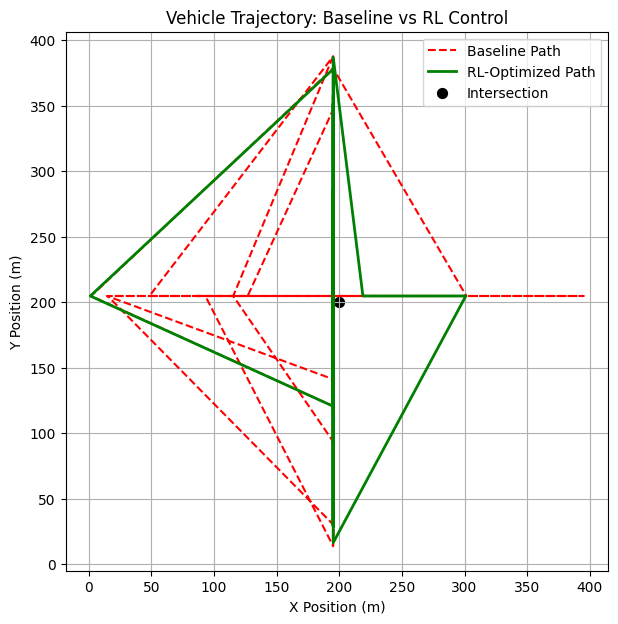

✅ Saved: vehicle_path_comparison.png


In [70]:


plt.figure(figsize=(7, 7))

plt.plot(
    baseline_path[:, 0],
    baseline_path[:, 1],
    '--',
    label='Baseline Path',
    color='red'
)

plt.plot(
    rl_path[:, 0],
    rl_path[:, 1],
    label='RL-Optimized Path',
    color='green',
    linewidth=2
)

plt.scatter(200, 200, c='black', s=50, label='Intersection')


plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Vehicle Trajectory: Baseline vs RL Control")
plt.legend()
plt.grid(True)

plt.savefig("vehicle_path_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: vehicle_path_comparison.png")


In [63]:
def predict_future_path(path, steps=30):
    """
    Linear short-horizon route prediction using last velocity.
    """
    if len(path) < 2:
        return None

    dx = path[-1, 0] - path[-2, 0]
    dy = path[-1, 1] - path[-2, 1]

    future = []
    x, y = path[-1]

    for _ in range(steps):
        x += dx
        y += dy
        future.append((x, y))

    return np.array(future)


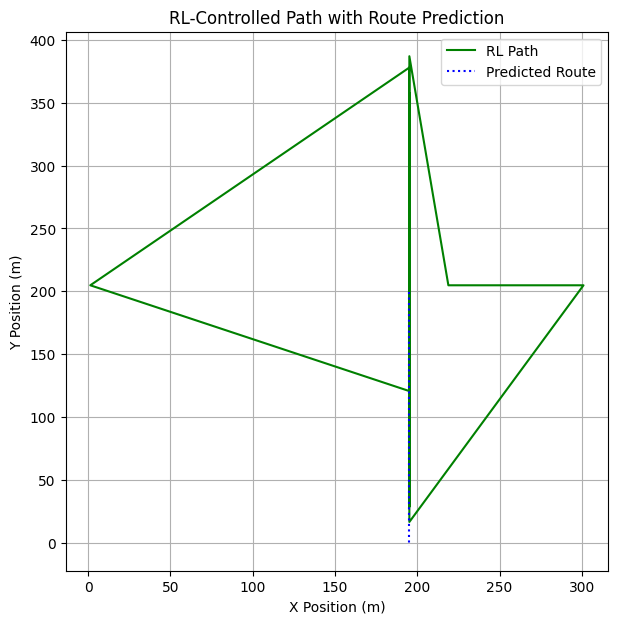

✅ Saved: rl_route_prediction.png


In [64]:
predicted_path = predict_future_path(rl_path, steps=25)

plt.figure(figsize=(7, 7))

plt.plot(
    rl_path[:, 0],
    rl_path[:, 1],
    label="RL Path",
    color="green"
)

if predicted_path is not None:
    plt.plot(
        predicted_path[:, 0],
        predicted_path[:, 1],
        ':',
        label="Predicted Route",
        color="blue"
    )

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("RL-Controlled Path with Route Prediction")
plt.legend()
plt.grid(True)

plt.savefig("rl_route_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Saved: rl_route_prediction.png")


---

## 📚 References for LaTeX Report

Include these in your IEEE format bibliography:

```bibtex
@article{schulman2017ppo,
  title={Proximal policy optimization algorithms},
  author={Schulman, John and Wolski, Filip and Dhariwal, Prafulla and Radford, Alec and Klimov, Oleg},
  journal={arXiv preprint arXiv:1707.06347},
  year={2017}
}

@inproceedings{lopez2018sumo,
  title={Microscopic traffic simulation using sumo},
  author={Lopez, Pablo Alvarez and others},
  booktitle={IEEE Intelligent Transportation Systems Conference},
  year={2018}
}
```

---

**End of Notebook**

Good luck with your CCP! 🚀